# Estratégias de imputação

**Tema:** Preparação de Dados › Dados Faltantes e Outliers

Como no notebook anterior, partimos de dados completos, apagamos parte deles,
e comparamos cada estratégia de imputação contra o valor **verdadeiro** que
só conhecemos porque simulamos os dados. Essa comparação com o "gabarito" é o
que dá substância à frase "imputação X é melhor que Y" — sem ela, é opinião.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(55)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. Dados completos com estrutura real entre colunas

Três variáveis correlacionadas: `idade`, `renda` (depende de idade) e
`gasto_mensal` (depende de renda). Vamos apagar ~25% de `renda`
aleatoriamente (MCAR, para isolar o efeito do MÉTODO de imputação do efeito
do MECANISMO, já coberto no notebook anterior).

In [2]:
n = 2000
idade = rng.normal(40, 12, n).clip(18, 75)
renda = (1500 + 110 * idade + rng.normal(0, 900, n)).clip(700, None)
gasto_mensal = (300 + 0.35 * renda + rng.normal(0, 400, n)).clip(50, None)

completo = pd.DataFrame({"idade": idade, "renda": renda, "gasto_mensal": gasto_mensal})
renda_verdadeira = renda.copy()

mascara = rng.random(n) < 0.25
com_nulos = completo.copy()
com_nulos.loc[mascara, "renda"] = np.nan

print(f"nulos em renda: {com_nulos['renda'].isna().sum()} de {n} "
      f"({com_nulos['renda'].isna().mean():.1%})")
print(f"\ncorrelação verdadeira idade-renda: {np.corrcoef(idade, renda)[0,1]:.4f}")
print(f"correlação verdadeira renda-gasto: {np.corrcoef(renda, gasto_mensal)[0,1]:.4f}")
print(f"desvio-padrão verdadeiro de renda: {renda.std(ddof=1):.1f}")

nulos em renda: 474 de 2000 (23.7%)

correlação verdadeira idade-renda: 0.8235
correlação verdadeira renda-gasto: 0.8024
desvio-padrão verdadeiro de renda: 1603.6


## 2. Imputação simples: média

Rápida, e com o efeito colateral previsto na teoria: achata a variância.

In [3]:
imputador_media = SimpleImputer(strategy="mean")
renda_imputada_media = imputador_media.fit_transform(com_nulos[["renda"]]).ravel()

print(f"desvio-padrão ANTES de apagar : {renda.std(ddof=1):.1f}")
print(f"desvio-padrão DEPOIS de imputar com a média: "
      f"{renda_imputada_media.std(ddof=1):.1f}")
print(f"redução: {(1 - renda_imputada_media.std(ddof=1)/renda.std(ddof=1)):.1%}")

erro_medio = np.abs(renda_imputada_media[mascara] - renda_verdadeira[mascara]).mean()
print(f"\nerro absoluto médio (só nos pontos que eram nulos): {erro_medio:.1f}")

desvio-padrão ANTES de apagar : 1603.6
desvio-padrão DEPOIS de imputar com a média: 1401.1
redução: 12.6%

erro absoluto médio (só nos pontos que eram nulos): 1288.8


## 3. Coluna indicadora: preservando o sinal de "foi imputado"

In [4]:
com_indicador = com_nulos.copy()
com_indicador["renda_era_nula"] = com_nulos["renda"].isna().astype(int)
com_indicador["renda"] = renda_imputada_media
print(com_indicador.head())
print("\nA coluna indicadora deixa explícito, para o modelo, quais valores são")
print("estimativas e quais são observações reais — informação que a imputação")
print("simples sozinha apaga.")

       idade        renda  gasto_mensal  renda_era_nula
0  50.107136  7451.917822   3161.313347               0
1  18.000000  2273.954923    892.876093               0
2  36.339713  7031.845779   3052.245536               0
3  57.398655  9549.717637   3527.456046               0
4  25.072462  5545.051901   2459.334496               0

A coluna indicadora deixa explícito, para o modelo, quais valores são
estimativas e quais são observações reais — informação que a imputação
simples sozinha apaga.


## 4. KNN: usando idade e gasto para estimar a renda faltante

Padronizar antes é obrigatório — `KNNImputer` mede distância, e sem
padronizar, a escala de `gasto_mensal` (centenas/milhares) dominaria `idade`
(dezenas), exatamente como no tema 2.

In [5]:
colunas = ["idade", "renda", "gasto_mensal"]
scaler = StandardScaler()
dados_padronizados = scaler.fit_transform(com_nulos[colunas])
dados_padronizados_df = pd.DataFrame(dados_padronizados, columns=colunas)

imputador_knn = KNNImputer(n_neighbors=10)
imputado_knn_padronizado = imputador_knn.fit_transform(dados_padronizados_df)

# desfazer a padronização para comparar na escala original
imputado_knn = scaler.inverse_transform(imputado_knn_padronizado)
renda_imputada_knn = imputado_knn[:, colunas.index("renda")]

erro_knn = np.abs(renda_imputada_knn[mascara] - renda_verdadeira[mascara]).mean()
print(f"erro absoluto médio (média)  : {erro_medio:.1f}")
print(f"erro absoluto médio (KNN, k=10): {erro_knn:.1f}")
print(f"\ndesvio-padrão (KNN): {renda_imputada_knn.std(ddof=1):.1f}  "
      f"(verdadeiro: {renda.std(ddof=1):.1f})")

erro absoluto médio (média)  : 1288.8
erro absoluto médio (KNN, k=10): 597.6

desvio-padrão (KNN): 1563.6  (verdadeiro: 1603.6)


## 5. MICE via `IterativeImputer`: usando a regressão entre as colunas

In [6]:
imputador_iterativo = IterativeImputer(random_state=0, max_iter=15)
imputado_mice = imputador_iterativo.fit_transform(com_nulos[colunas])
renda_imputada_mice = imputado_mice[:, colunas.index("renda")]

erro_mice = np.abs(renda_imputada_mice[mascara] - renda_verdadeira[mascara]).mean()
print(f"erro absoluto médio (média)   : {erro_medio:.1f}")
print(f"erro absoluto médio (KNN)     : {erro_knn:.1f}")
print(f"erro absoluto médio (MICE)    : {erro_mice:.1f}")
print(f"\ndesvio-padrão (MICE): {renda_imputada_mice.std(ddof=1):.1f}  "
      f"(verdadeiro: {renda.std(ddof=1):.1f})")

erro absoluto médio (média)   : 1288.8
erro absoluto médio (KNN)     : 597.6
erro absoluto médio (MICE)    : 587.0

desvio-padrão (MICE): 1569.8  (verdadeiro: 1603.6)


## 6. Comparando as três estratégias lado a lado

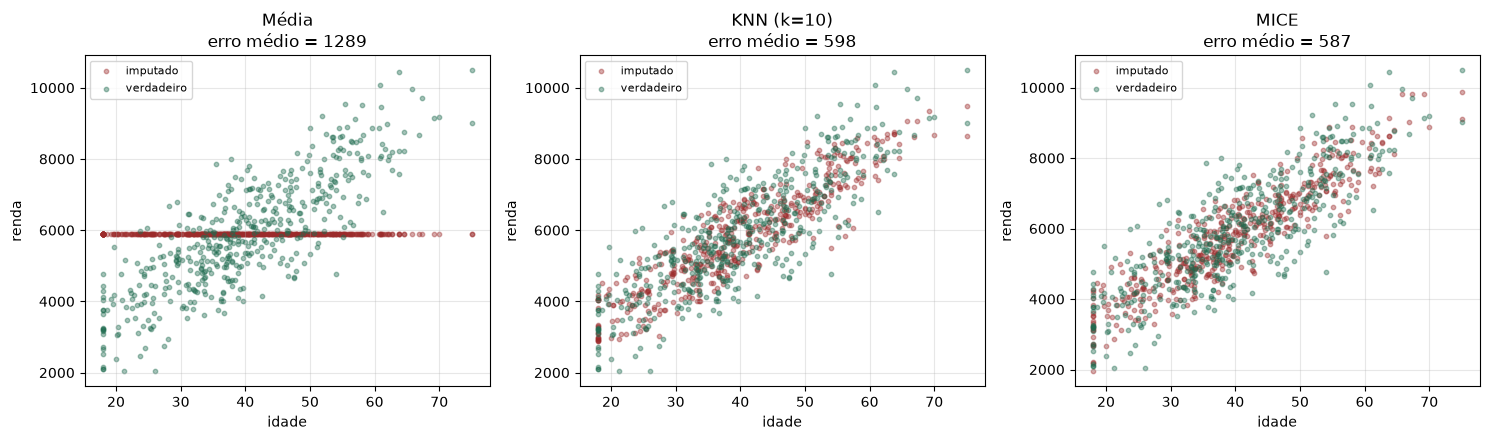

método          erro absoluto médio   desvio-padrão recuperado   correlação c/ idade recuperada
------------------------------------------------------------------------------------------------
(verdadeiro)                      —                     1603.6                           0.8235
Média                        1288.8                     1401.1                           0.7153
KNN (k=10)                    597.6                     1563.6                           0.8382
MICE                          587.0                     1569.8                           0.8415


In [7]:
metodos = {
    "Média": renda_imputada_media,
    "KNN (k=10)": renda_imputada_knn,
    "MICE": renda_imputada_mice,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (nome, valores) in zip(axes, metodos.items()):
    ax.scatter(idade[mascara], valores[mascara], s=10, alpha=0.4, color=VERMELHO,
              label="imputado")
    ax.scatter(idade[mascara], renda_verdadeira[mascara], s=10, alpha=0.4,
              color=VERDE, label="verdadeiro")
    erro = np.abs(valores[mascara] - renda_verdadeira[mascara]).mean()
    ax.set_title(f"{nome}\nerro médio = {erro:.0f}")
    ax.set_xlabel("idade"); ax.set_ylabel("renda")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"{'método':<14s} {'erro absoluto médio':>20s} {'desvio-padrão recuperado':>26s} "
      f"{'correlação c/ idade recuperada':>32s}")
print("-" * 96)
print(f"{'(verdadeiro)':<14s} {'—':>20s} {renda.std(ddof=1):>26.1f} "
      f"{np.corrcoef(idade, renda)[0,1]:>32.4f}")
for nome, valores in metodos.items():
    erro = np.abs(valores[mascara] - renda_verdadeira[mascara]).mean()
    corr = np.corrcoef(idade, valores)[0, 1]
    print(f"{nome:<14s} {erro:>20.1f} {valores.std(ddof=1):>26.1f} {corr:>32.4f}")

**Leitura esperada:** a média recupera o pior desvio-padrão (achata a
variância na proporção exata dos nulos) e a pior correlação com idade
(substitui todo nulo pelo mesmo número, destruindo qualquer relação). KNN e
MICE, ao usar as outras colunas, preservam melhor tanto a variância quanto a
correlação — porque usam a estrutura real dos dados em vez de ignorá-la.

## 7. A armadilha do vazamento: ajustar o imputador no dataset inteiro

In [8]:
from sklearn.model_selection import train_test_split

treino, teste = train_test_split(com_nulos[colunas], test_size=0.3, random_state=0)

# ERRADO: fit no dataset inteiro (treino + teste) antes de dividir
imputador_errado = SimpleImputer(strategy="mean").fit(com_nulos[["renda"]])
media_vazada = imputador_errado.statistics_[0]

# CERTO: fit só no treino
imputador_certo = SimpleImputer(strategy="mean").fit(treino[["renda"]])
media_correta = imputador_certo.statistics_[0]

print(f"média usada para imputar (fit no dataset INTEIRO): {media_vazada:.2f}")
print(f"média usada para imputar (fit só no TREINO)       : {media_correta:.2f}")
print(f"\ndiferença: {abs(media_vazada - media_correta):.2f}")
print("Pequena aqui porque o split é aleatório e MCAR — mas em produção, o")
print("'dataset inteiro' no treino é informação que na vida real NÃO existe")
print("no momento de treinar (o teste representa o futuro). É a mesma lógica")
print("de vazamento que o módulo 4 formaliza com Pipeline.")

média usada para imputar (fit no dataset INTEIRO): 5901.84
média usada para imputar (fit só no TREINO)       : 5888.33

diferença: 13.51
Pequena aqui porque o split é aleatório e MCAR — mas em produção, o
'dataset inteiro' no treino é informação que na vida real NÃO existe
no momento de treinar (o teste representa o futuro). É a mesma lógica
de vazamento que o módulo 4 formaliza com Pipeline.


## O que levar deste notebook

- Imputação por média é a mais simples e a que mais distorce variância e
  correlação — proporcional à fração de dados faltantes.
- Uma coluna indicadora de "era nulo" preserva informação que a imputação
  sozinha apaga, especialmente útil sob MAR/MNAR.
- KNN e MICE usam a estrutura entre colunas para produzir estimativas mais
  próximas do valor real — mensurável quando se conhece o "gabarito", como
  neste notebook simulado.
- O imputador (qualquer um) deve ser ajustado **só no treino** — ajustá-lo no
  dataset inteiro vaza informação do teste, mesmo que o efeito pareça pequeno
  em alguns casos.

→ Próximo: **Outliers** — detecção, e o que fazer depois de encontrar um.